<a href="https://colab.research.google.com/github/kkbin505/MEng_classify_fashion_MNIST/blob/vgg/vgg_Fashion_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


# Step 1: Load the Fashion-MNIST dataset by Keras

In [3]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Train images:", x_train.shape)
print("Test images:", x_test.shape)

class_names = ["T-shirt/top","Trouser","Pullover","Dress","Coat",
               "Sandal","Shirt","Sneaker","Bag","Ankle boot"]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train images: (60000, 28, 28)
Test images: (10000, 28, 28)


# Step 2: Optional Visualization

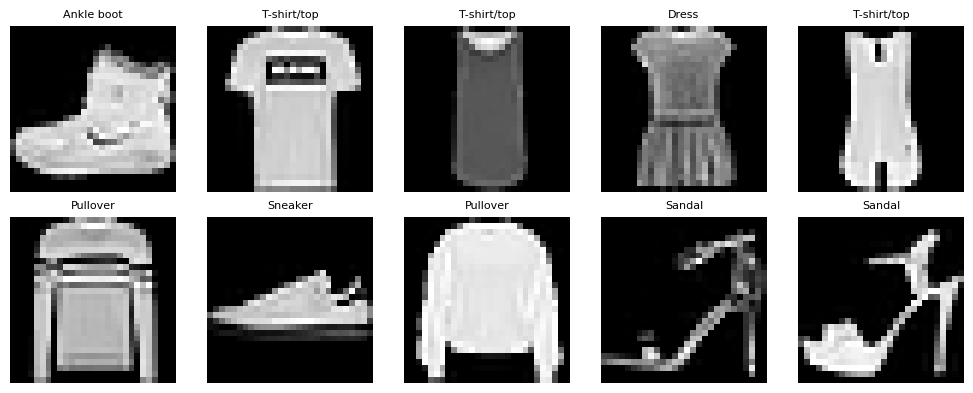

In [4]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]], fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

# Step 3: Data preprocessing

*   Normalize to [0,1]
*   Increase the channel dimension (28, 28) -> (28, 28, 1)



In [5]:
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test, -1)

print("Train images after reshape:", x_train.shape)
print("Test images after reshape:", x_test.shape)

Train images after reshape: (60000, 28, 28, 1)
Test images after reshape: (10000, 28, 28, 1)


# Step 4: VGG-style CNN model

* Two convolutional blocks, each Block: Conv3x3 + Conv3x3 + MaxPool
* VGG style: Only 3x3 convolution and 2x2 pooling are used

In [6]:
def build_vgg_style_fashion(input_shape=(28, 28, 1), num_classes=10):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_vgg_style_fashion()
model.summary()
print("Total params:", model.count_params())


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 467,818 (1.78 MB)

 Trainable params: 467,818 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

Total params: 467818


# Step 5: Model compiling

In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Step 6: Model training

* A 10% training set is used for validation
* Epochs/batch_size can be adjusted according to the time

In [8]:
epochs = 20
batch_size = 64

history = model.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 246s 288ms/step - accuracy: 0.7292 - loss: 0.7564 - val_accuracy: 0.8845 - val_loss: 0.3020
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 222s 262ms/step - accuracy: 0.8766 - loss: 0.3406 - val_accuracy: 0.9038 - val_loss: 0.2701
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 223s 264ms/step - accuracy: 0.8984 - loss: 0.2804 - val_accuracy: 0.9157 - val_loss: 0.2292
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 221s 262ms/step - accuracy: 0.9084 - loss: 0.2562 - val_accuracy: 0.9105 - val_loss: 0.2433
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 221s 262ms/step - accuracy: 0.9192 - loss: 0.2256 - val_accuracy: 0.9202 - val_loss: 0.2114
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 223s 264ms/step - accuracy: 0.9281 - loss: 0.1993 - val_accuracy: 0.9212 - val_loss: 0.2141
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 226s 268ms/step - accuracy: 0.9329 - loss: 0.1822 - val_accuracy: 0.9252 - val_loss: 0.2161
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 222s 263ms/step - accuracy: 0.9408 -

# Step 7: Test set evaluation

In [9]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss: 0.3468
Test accuracy: 0.9265


# Step 8: Loss/accuracy curve

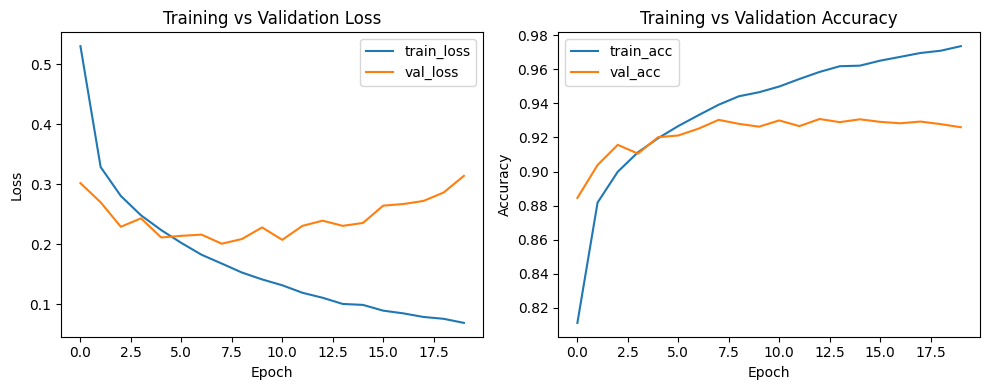

In [10]:
def plot_history(history):
    hist = history.history

    # Loss
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(hist['loss'], label='train_loss')
    plt.plot(hist['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(hist['accuracy'], label='train_acc')
    plt.plot(hist['val_accuracy'], label='val_acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

# Step 9: Confusion matrix + classification report

In [11]:
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step
Confusion matrix:
 [[898   0  16  10   3   1  68   0   4   0]
 [  0 987   0   6   0   0   5   0   2   0]
 [ 16   1 885   5  52   0  41   0   0   0]
 [ 12   0  10 928  28   0  21   0   1   0]
 [  2   1  23  18 930   0  26   0   0   0]
 [  0   0   0   0   0 991   0   7   0   2]
 [109   1  39  22  95   0 726   0   8   0]
 [  0   0   0   0   0   7   0 973   0  20]
 [  4   0   0   2   2   1   2   4 985   0]
 [  0   0   0   0   0   9   1  28   0 962]]

Classification report:
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.90      0.88      1000
     Trouser       1.00      0.99      0.99      1000
    Pullover       0.91      0.89      0.90      1000
       Dress       0.94      0.93      0.93      1000
        Coat       0.84      0.93      0.88      1000
      Sandal       0.98      0.99      0.99      1000
       Shirt       0.82      0.73      0.77      1000
     Sneaker       0.96      0.97      0.97      1

# Step 10: Prediction visualization

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
True label: Ankle boot
Predicted: Ankle boot (100.00%)


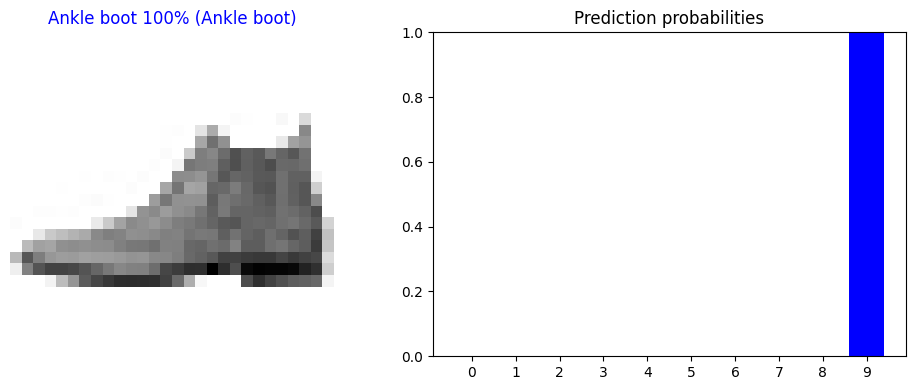

In [16]:
import matplotlib.pyplot as plt

# First image (index 0)
i = 0
image = x_test[i]
label = y_test[i]

# Model prediction (softmax vector)
pred = model.predict(image[np.newaxis, ...])[0]
pred_label = np.argmax(pred)

print("True label:", class_names[label])
print("Predicted:", class_names[pred_label], f"({pred[pred_label]*100:.2f}%)")

# Plot
plt.figure(figsize=(10,4))

# Image panel
plt.subplot(1,2,1)
plt.imshow(image.squeeze(), cmap="binary")
plt.axis("off")
pred_text = f"{class_names[pred_label]} {pred[pred_label]*100:.0f}% ({class_names[label]})"
color = 'blue' if pred_label == label else 'red'
plt.title(pred_text, color=color)

# Probability bar chart
plt.subplot(1,2,2)
plt.bar(range(10), pred, color=['blue' if i == pred_label else 'gray' for i in range(10)])
plt.xticks(range(10))
plt.ylim([0, 1])
plt.title("Prediction probabilities")

plt.tight_layout()
plt.show()
